In [4]:
from langgraph.graph import StateGraph, START,END, MessagesState

In [2]:
from dotenv import load_dotenv

In [3]:
from langchain.chat_models import init_chat_model

In [5]:
load_dotenv()

True

In [6]:
import os

In [9]:
chat_model = os.getenv('CHAT_MODEL')
llm = init_chat_model(model=chat_model)
llm.invoke('Hi')

AIMessage(content='Hi! 👋 How can I help you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 14, 'prompt_tokens': 7, 'total_tokens': 21, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-nano-2026-03-17', 'system_fingerprint': None, 'id': 'chatcmpl-EF5ZyPMCtO1JU0QCbDBpRGf0i7Dhu', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--01a0214c-beaa-7d51-9767-aa8e8d999441-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 7, 'output_tokens': 14, 'total_tokens': 21, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

In [11]:
def chat_bot(state: MessagesState):
    response = llm.invoke(state["messages"])
    return {"messages":[response]}

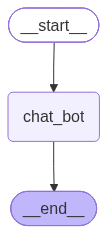

In [16]:
graph = StateGraph(MessagesState)

graph.add_node('chat_bot',chat_bot)

graph.add_edge(START,'chat_bot')
graph.add_edge('chat_bot',END)

workflow = graph.compile()

## Display
from IPython.display import Image, display
display(Image(workflow.get_graph().draw_mermaid_png()))

In [18]:
message = {
        'messages':[
            {
                'role':'user',
                'content':'Hi my name is tej.'
            }
        ]
    }

In [19]:
response = workflow.invoke(message)

In [21]:
response

{'messages': [HumanMessage(content='Hi my name is tej.', additional_kwargs={}, response_metadata={}, id='b2a5c6c3-87e5-4c5a-8c85-7bdf34017b6e'),
  AIMessage(content='Hi Tej! Nice to meet you 😊  \nHow can I help you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 20, 'prompt_tokens': 12, 'total_tokens': 32, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-nano-2026-03-17', 'system_fingerprint': None, 'id': 'chatcmpl-EF5jGnSaf7o0HAR3ss3jP0djXlX2c', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--01a02155-8d72-7ba2-bcd3-5f996c0fd58d-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 12, 'output_tokens': 20, 'total_tokens': 32, 'input_token_details

In [22]:
response["messages"][-1].content

'Hi Tej! Nice to meet you 😊  \nHow can I help you today?'

In [24]:
print('To end: exit,q,quit')
while True:
    
    _input = input('User: ')

    if _input in ('q','quit','exit'):
        break
    
    message = {
        'messages':[
            {
                'role':'user',
                'content':_input
            }
        ]
    }

    response  = workflow.invoke(message)
    print('User: ', _input)
    print('AI: ',response["messages"][-1].content)

To end: exit,q,quit
User:  Hi
AI:  Hi! How can I help you today?
User:  My name i tej
AI:  Hi Tej! Nice to meet you. 😊 What would you like to do today?
User:  what is my name
AI:  I don’t know your name from this chat. If you tell me your name, I can remember it for future messages.
User:  
AI:  Hi! What would you like help with?


# Checkpoint saver

In [26]:
from langgraph.checkpoint.memory import InMemorySaver

checkpointer = InMemorySaver()

In [27]:
checkpoint_graph = graph.compile(checkpointer)

In [47]:
print('To end: exit,q,quit')

_user_id = None 

while True:

    if not _user_id : 
        _user_id = input('User id: ')

    _input = input('User: ')
    
    if _input in ('q','quit','exit'):
        _user_id = None
        break
    
    message = {
        'messages':[
            {
                'role':'user',
                'content':_input
            }
        ]
    }

    config = {
        'configurable':{
            'thread_id':_user_id
        }
    }

    response  = checkpoint_graph.invoke(message,config)
    print('User: ', _input)
    print('AI: ',response["messages"][-1].content)

To end: exit,q,quit
User:  my name is riya
AI:  Hi Riya! Nice to meet you 😊  
How can I help you today?
User:  what is my name
AI:  Your name is **Riya**.


In [38]:
dir(checkpoint_graph)

['InputType',
 'OutputType',
 '__abstractmethods__',
 '__annotations__',
 '__class__',
 '__class_getitem__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__or__',
 '__orig_bases__',
 '__orig_class__',
 '__parameters__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__ror__',
 '__setattr__',
 '__sizeof__',
 '__slots__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_abatch_with_config',
 '_abc_impl',
 '_acall_with_config',
 '_apply_checkpointer_allowlist',
 '_apregel_stream_v3',
 '_aprepare_state_snapshot',
 '_astream_events_v1_v2',
 '_astream_events_v3_unsupported',
 '_atransform_stream_with_config',
 '_batch_with_config',
 '_call_with_config',
 '_defaults',
 '_migrate_checkpoint',
 '_output_mapper',
 '_pregel_stream_v3',
 '_prepare_state_snapshot',
 '_repr_mimebundle_',
 '_serd

In [50]:
config = {
        'configurable':{
            'thread_id':2
        }
    }


snap = checkpoint_graph.get_state(config)
vals = snap.values
for m in vals.get("messages", []):
        print("-", type(m).__name__, ":", m.content)

- HumanMessage : my name is riya
- AIMessage : Hi Riya! Nice to meet you 😊  
How can I help you today?
- HumanMessage : what is my name
- AIMessage : Your name is **Riya**.
